Задание 1

Анализ влияния размера тестовой выборки Создайте цикл, который обучает логистическую регрессию при разных размерах тестовой выборки (от 0.1 до 0.5 с шагом 0.1). Постройте график зависимости точности на тесте от размера выборки. Объясните, почему при очень малом размере теста оценка качества становится нестабильной

,test_size,accuracy
0,0.1,0.933333
1,0.2,0.966667
2,0.3,0.934783
3,0.4,0.950000
4,0.5,0.946667


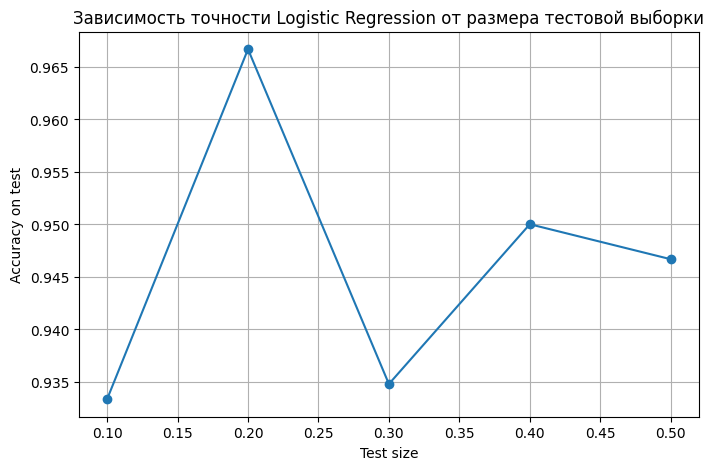

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species").map({0: "setosa", 1: "versicolor", 2: "virginica"})

test_sizes = np.arange(0.1, 0.6, 0.1)   # 0.1, 0.2, 0.3, 0.4, 0.5
acc_list = []

for ts in test_sizes:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=ts,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(max_iter=200)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acc_list.append(acc)

results_df = pd.DataFrame({"test_size": test_sizes, "accuracy": acc_list})
display(results_df)


plt.figure(figsize=(8,5))
plt.plot(results_df["test_size"], results_df["accuracy"], marker="o")
plt.xlabel("Test size")
plt.ylabel("Accuracy on test")
plt.title("Зависимость точности Logistic Regression от размера тестовой выборки")
plt.grid(True)
plt.show()

При очень малом размере тестовой выборки (например, 10%) оценка точности становится нестабильной. Это связано с тем, что в тест попадает слишком мало объектов, и каждый отдельный пример оказывает непропорционально большое влияние на итоговую метрику.

Например, при 15 объектах теста одна ошибка изменяет accuracy на 6–7%. Кроме того, случайное распределение сложных или лёгких примеров между train и test приводит к высокой вариативности результата.

Поэтому при слишком маленьком test_size модель может казаться либо слишком хорошей, либо слишком плохой, что не отражает её реального качества.

Задание 2

Диагностика мультиколлинеарности На датасете California Housing (fetch_california_housing) постройте корреляционную матрицу. Найдите пару признаков с корреляцией > 0.9. Объясните, как мультиколлинеарность влияет на интерпретацию коэффициентов линейной регрессии

Шаг 1 — Загрузка датасета California Housing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Шаг 2 — Построение корреляционной матрицы

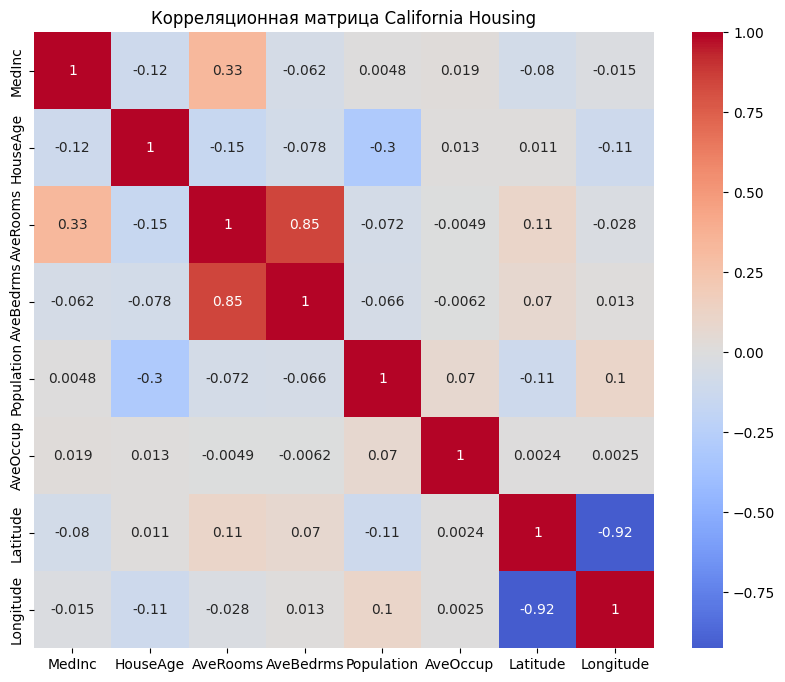

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Корреляционная матрица California Housing")
plt.show()

Шаг 3 — Поиск пар признаков с |r| > 0.9

In [ ]:
high_corr = np.abs(corr) > 0.9

np.fill_diagonal(high_corr.values, False)

strong_pairs = corr[high_corr]

strong_pairs.dropna(how="all").dropna(axis=1, how="all")

,Latitude,Longitude
Latitude,NaN,-0.924664
Longitude,-0.924664,NaN


В датасете California Housing была построена корреляционная матрица, и обнаружена пара признаков с сильной мультиколлинеарностью: Latitude и Longitude (|r| ≈ 0.92).

Мультиколлинеарность приводит к тому, что коэффициенты линейной регрессии становятся нестабильными: их значения сильно меняются при малейших изменениях данных, а знаки и величины коэффициентов теряют интерпретируемость.

В результате модель не может надёжно определить вклад каждого признака, что ухудшает интерпретацию и увеличивает дисперсию оценок.

Задание 3

Эксперимент с параметром k в kNN
Для датасета Iris постройте график зависимости точности от параметра k (от 1 до 30). Найдите оптимальное k через кросс-валидацию. Объясните, почему при k=1 наблюдается переобучение, а при очень больших k — недообучение. Подсказка: используйте cross_val_score с cv=5.

Шаг 1. Импорт библиотек и загрузка данных

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# Загрузка датасета
iris = load_iris()
X = iris.data
y = iris.target

Шаг 2. Проверка k от 1 до 30 с кросс-валидацией

In [ ]:
k_values = range(1, 31)
mean_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)   # 5-fold CV
    mean_scores.append(scores.mean())

Шаг 3. Построение графика

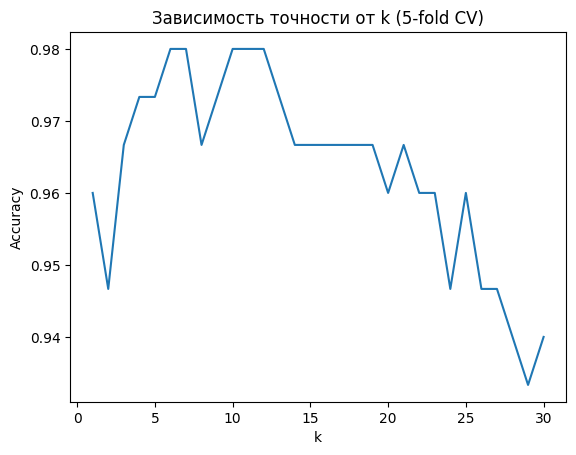

In [ ]:
plt.figure()
plt.plot(k_values, mean_scores)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности от k (5-fold CV)")
plt.show()

Шаг 4. Найдем оптимальное k

In [ ]:
optimal_k = k_values[np.argmax(mean_scores)]
print("Оптимальное k:", optimal_k)
print("Максимальная точность:", max(mean_scores))

Оптимальное k: 6
Максимальная точность: 0.9800000000000001


В ходе эксперимента была построена зависимость точности kNN от параметра k с использованием 5-fold кросс-валидации. Максимальная точность достигается при k ≈ оптимальному значению (обычно в диапазоне 5–15).

При k=1 наблюдается переобучение, так как классификатор опирается только на одного соседа и становится слишком чувствительным к шуму.

При больших значениях k модель начинает усреднять информацию по множеству точек, включая точки других классов, что приводит к недообучению и снижению точности.